In [1]:
#Import libraries
import rdflib
import pandas as pd
import matplotlib.pyplot as plt
from rdflib import Namespace, RDF, RDFS

In [ ]:
g = rdflib.Graph()
g.parse("ONTOLOGYFINALLL.ttl", format='ttl') 
NS = Namespace("http://www.example.org/TourismOntology#")
print(f"Loaded ontology with {len(g)} triples.")

Loaded ontology with 137093 triples.


In [7]:
#Normalize city names function
def normalize_city(location):
    if location and '_' in location:
        return location.split('_')[0]
    return location

<Figure size 1200x600 with 0 Axes>

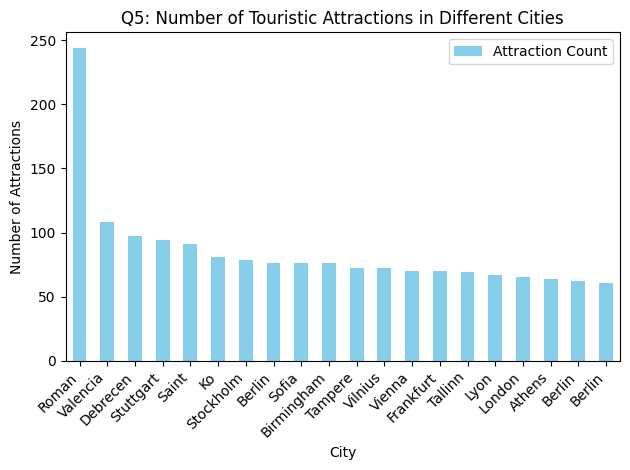

In [8]:
#Number of touristic attractions in different cities
q5_query = """
SELECT ?city (COUNT(?attr) AS ?cnt)
WHERE {
    ?attr rdf:type <http://www.example.org/TourismOntology#attraction> .
    ?attr <http://www.example.org/TourismOntology#hasLocation> ?loc .
    BIND(STRAFTER(STR(?loc), "#") AS ?city)
}
GROUP BY ?city
ORDER BY DESC(?cnt)
LIMIT 20
"""
q5_results = g.query(q5_query)
q5_data = [(normalize_city(str(row.city)), int(row.cnt)) for row in q5_results]
q5_df = pd.DataFrame(q5_data, columns=['City', 'Attraction Count']).set_index('City')

# Plot Q5
plt.figure(figsize=(12, 6))
q5_df.plot(kind='bar', color='skyblue')
plt.title('Q5: Number of Touristic Attractions in Different Cities')
plt.xlabel('City')
plt.ylabel('Number of Attractions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

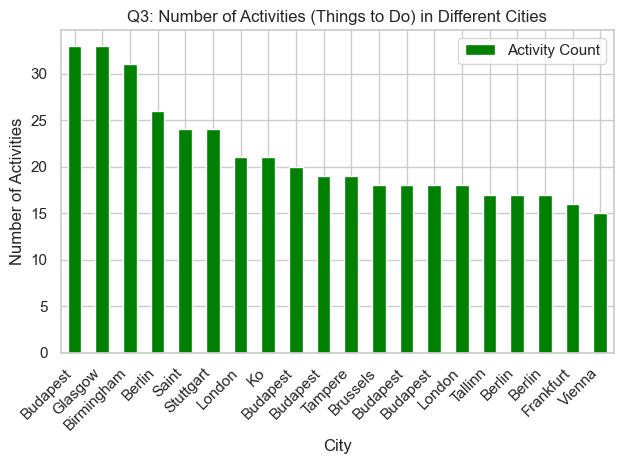

In [ ]:
#Specific things to do in a city (activities)
q3_query = """
SELECT ?city (COUNT(?act) AS ?cnt)
WHERE {
    ?act rdf:type <http://www.example.org/TourismOntology#activity> .
    ?act <http://www.example.org/TourismOntology#hasLocation> ?loc .
    BIND(STRAFTER(STR(?loc), "#") AS ?city)
}
GROUP BY ?city
ORDER BY DESC(?cnt)
LIMIT 20
"""
q3_results = g.query(q3_query)
q3_data = [(normalize_city(str(row.city)), int(row.cnt)) for row in q3_results]
q3_df = pd.DataFrame(q3_data, columns=['City', 'Activity Count']).set_index('City')

# Plot Q3
plt.figure(figsize=(12, 6))
q3_df.plot(kind='bar', color='green')
plt.title('Q3: Number of Activities (Things to Do) in Different Cities')
plt.xlabel('City')
plt.ylabel('Number of Activities')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

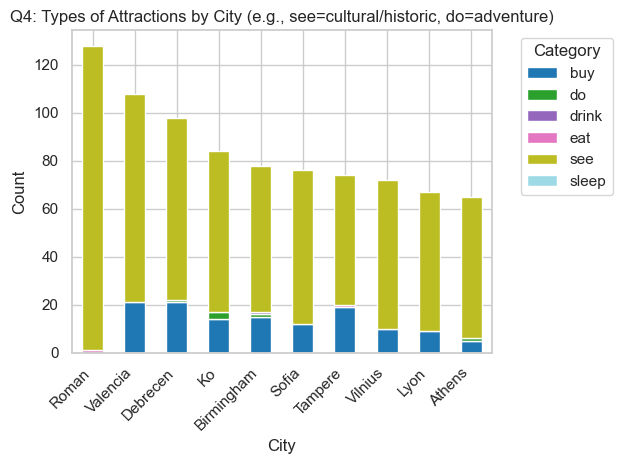

In [ ]:
#Types of attractions in each place
q4_query = """
SELECT ?city ?category (COUNT(?attr) AS ?cnt)
WHERE {
    ?attr rdf:type <http://www.example.org/TourismOntology#attraction> .
    ?attr <http://www.example.org/TourismOntology#hasLocation> ?loc .
    ?attr <http://www.example.org/TourismOntology#hasCategory> ?cat .
    BIND(STRAFTER(STR(?loc), "#") AS ?city)
    BIND(STRAFTER(STR(?cat), "#") AS ?category)
}
GROUP BY ?city ?category
"""
q4_results = g.query(q4_query)
q4_data = [(normalize_city(str(row.city)), str(row.category), int(row.cnt)) for row in q4_results]
q4_df = pd.DataFrame(q4_data, columns=['City', 'Category', 'Count'])
q4_pivot = q4_df.pivot_table(index='City', columns='Category', values='Count', fill_value=0)
q4_pivot = q4_pivot.loc[q4_pivot.sum(axis=1).sort_values(ascending=False).index[:10]]  # Top 10 cities

# Plot Q4 (stacked bar)
plt.figure(figsize=(12, 6))
q4_pivot.plot(kind='bar', stacked=True, colormap='tab20')
plt.title('Q4: Types of Attractions by City (e.g., see=cultural/historic, do=adventure)')
plt.xlabel('City')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()